# Surface renewal on one day of real data — WES almond orchard, 9 July 2025

This notebook runs both `srflux` detectors end to end on a single day from an almond
orchard eddy-covariance site, and calibrates them against the tower.

**What is in `examples/data/`**

| file | contents |
|---|---|
| `wes_2025-07-09_1hz.csv.gz` | 1 Hz **FWT** (fine-wire thermocouple, air), **IRT** (radiometer target = canopy skin) and **SBT** (the radiometer's own housing thermistor), 86,400 samples |
| `wes_2025-07-09_flux30.csv` | 30-min **NETRAD**, **G**, **H**, **LE** from the tower (48 blocks) |

Nothing else is needed: the two temperature series are the surface-renewal input, and the
four flux terms are the reference and the energy balance.

*The day was picked from summer 2025 for complete flux coverage and strong SR-WL skill on
the skin channel. Choosing a day by the statistic the notebook then reports inflates it —
read what follows as a demonstration of the workflow, not as a validation of the site.*

**Timestamp convention: every timestamp labels the START of its period.** A row stamped
12:00 in the flux file is the average over 12:00–12:30, and the 1 Hz block grouped at 12:00
covers the same half hour. `pd.Grouper(freq="30min")` is left-labelled and left-closed, which
is why the two join directly. This was verified rather than assumed: with the mean diurnal
cycle removed, the fine wire (IRT logger) correlates with the air temperature (EC logger)
best at zero shift, and the correlation drops on either side — a half-hour misalignment
would have peaked at ±1 block.

The `NETRAD` and `G` columns are QC'd, partly gap-filled products rather than raw sensor
readings (net radiation reconstructed against clear-sky models; soil heat flux with per-plate
flagging and 2–6 cm storage), so treat them as the pipeline's best estimate of the energy
balance rather than as measurements.

The two ramp scalars are a deliberate contrast. FWT sits in the air and sees the sharp
microfronts directly; IRT looks at the canopy skin, whose ramps are smoother, smaller and
harder to detect — which is exactly where surface renewal is most useful, because a
radiometer is cheap and needs no sonic.

The third channel, **SBT**, is not a ramp scalar at all. It is the thermistor inside the
radiometer housing, which equilibrates with the *air* rather than the canopy, so the
difference `dT = IRT − SBT ≈ Ts − Ta` is available from the single instrument. Section 6
uses it for the flux direction and the stability class, which is otherwise the one thing
surface renewal cannot get from a radiometer alone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from srflux import (HaarDetector, VanAttaDetector, prepare_block, ramp_flux,
                    calibrate_alpha, fit_and_score, sensible_heat,
                    latent_heat_residual, daily_et, sign_from_skewness,
                    sign_from_gradient, fit_gradient_offset, stability_from_gradient,
                    surface_air_difference)
from srflux.preprocess import increment_skewness

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

FS = 1.0            # Hz, the raw sampling rate
BLOCK_S = 1800.0    # 30-min averaging period
Z_AIR = 7.5         # m, sonic/fine-wire measurement height
Z_CANOPY = 3.5      # m, canopy height -- the right length scale for a SKIN temperature

hi = pd.read_csv("data/wes_2025-07-09_1hz.csv.gz", parse_dates=["TIMESTAMP"])
fx = pd.read_csv("data/wes_2025-07-09_flux30.csv", parse_dates=["TIMESTAMP"])
hi = hi.set_index("TIMESTAMP")
fx = fx.set_index("TIMESTAMP")

print(hi.describe().round(2).to_string())
fx.head()

            FWT       IRT       SBT
count  86400.00  86400.00  86400.00
mean      21.48     19.91     21.08
std        6.05      6.05      6.45
min       12.25     11.27     11.44
25%       15.43     14.48     15.73
50%       20.66     19.09     20.73
75%       27.86     26.28     27.88
max       30.96     29.25     30.05


,NETRAD,G,H,LE
TIMESTAMP,,,,
2025-07-09 00:00:00,-73.64,-45.85,-11.80,6.97
2025-07-09 00:30:00,-71.91,-44.66,-14.20,5.55
2025-07-09 01:00:00,-67.00,-44.69,NaN,4.69
2025-07-09 01:30:00,-55.72,-43.99,-13.37,0.59
2025-07-09 02:00:00,-49.06,-44.26,-4.38,1.13


## 1. The day at a glance

Top: the two raw 1 Hz series. The fine wire tracks air temperature and is visibly noisier;
the canopy skin runs *below* air through the middle of the day, which is what a transpiring
orchard should do — evaporative cooling holds the leaves below the air around them.

Bottom: the surface energy balance. This is an irrigated orchard in June, so most of the
available energy goes into LE, and H is the smaller term. That matters later: an error in
the surface-renewal H is diluted when ET is computed as a residual.

daytime Bowen ratio  H/LE = 0.24
energy-balance closure (H+LE)/(Rn-G) = 1.01


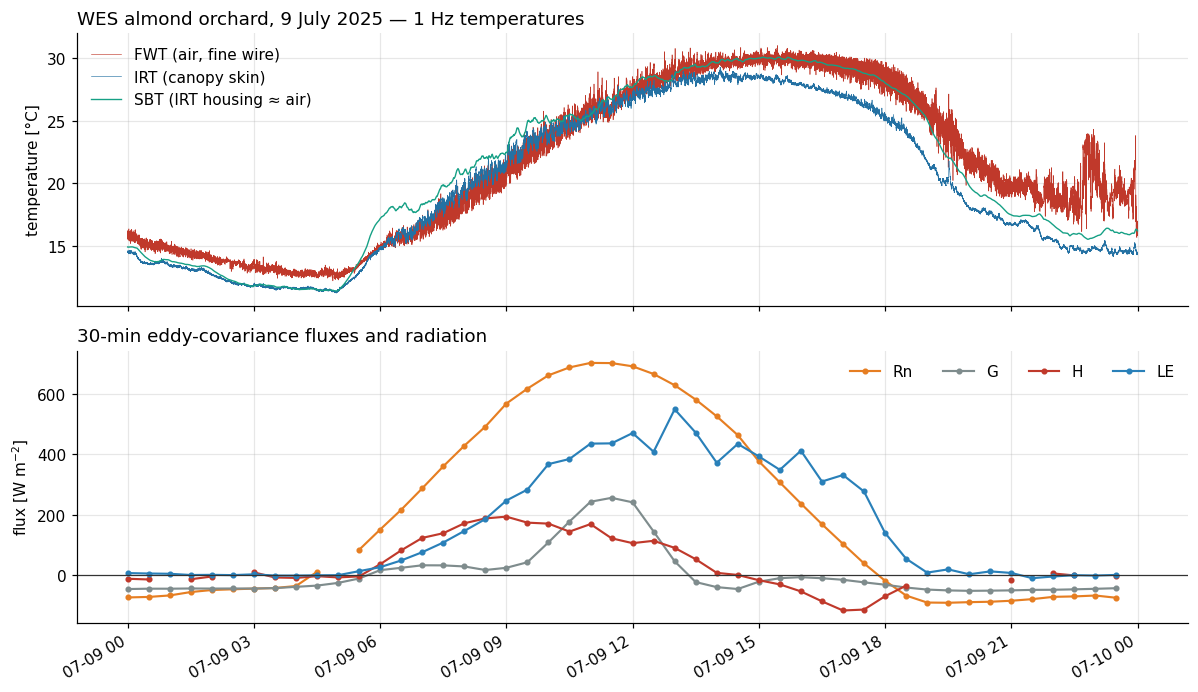

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 1]))

ax1.plot(hi.index, hi.FWT, lw=0.4, color="#c0392b", label="FWT (air, fine wire)")
ax1.plot(hi.index, hi.IRT, lw=0.4, color="#2471a3", label="IRT (canopy skin)")
ax1.plot(hi.index, hi.SBT, lw=0.9, color="#16a085", label="SBT (IRT housing ≈ air)")
ax1.set_ylabel("temperature [°C]")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("WES almond orchard, 9 July 2025 — 1 Hz temperatures", loc="left")

for col, clr, lab in [("NETRAD", "#e67e22", "Rn"), ("G", "#7f8c8d", "G"),
                      ("H", "#c0392b", "H"), ("LE", "#2980b9", "LE")]:
    ax2.plot(fx.index, fx[col], "-o", ms=3, lw=1.4, color=clr, label=lab)
ax2.axhline(0, color="#333", lw=0.8)
ax2.set_ylabel("flux [W m$^{-2}$]")
ax2.legend(ncol=4, frameon=False)
ax2.set_title("30-min eddy-covariance fluxes and radiation", loc="left")
fig.autofmt_xdate()
plt.tight_layout()

closure = (fx.H + fx.LE).sum() / (fx.NETRAD - fx.G).sum()
print(f"daytime Bowen ratio  H/LE = {fx.H[fx.NETRAD > 50].sum() / fx.LE[fx.NETRAD > 50].sum():.2f}")
print(f"energy-balance closure (H+LE)/(Rn-G) = {closure:.2f}")

## 2. What a ramp actually looks like

One 30-min block at midday, for both scalars. The top panels show the raw series with its
300 s moving mean; the bottom panels show the detrended signal and the Haar coefficients,
with the detected microfronts marked.

Detection runs on the whole 30-min block; the plot shows the first few minutes so the
individual ramps stay legible. Note the difference in vertical scale — the air ramps are
several times larger than the skin ramps — and look at the asymmetry of each ramp, which
is what section 6 turns out to depend on.

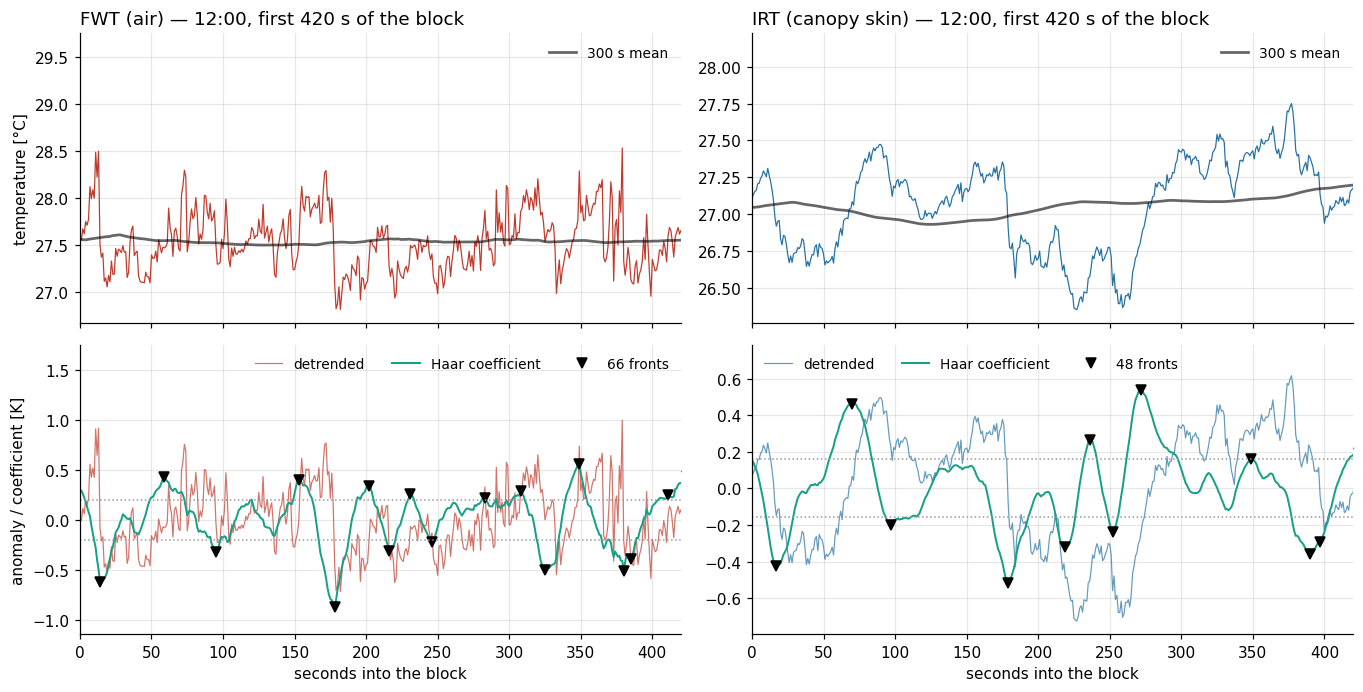

In [3]:
from srflux.preprocess import moving_average

t0 = pd.Timestamp("2025-07-09 12:00:00")
ZOOM_S = 420          # plot this many seconds so individual ramps stay legible
seg = hi.loc[t0:t0 + pd.Timedelta(seconds=BLOCK_S - 1)]
det = HaarDetector(fs=FS)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4), sharex=True)
for j, (col, clr, lab) in enumerate([("FWT", "#c0392b", "FWT (air)"),
                                     ("IRT", "#2471a3", "IRT (canopy skin)")]):
    v = prepare_block(seg[col].to_numpy(), fs=FS).values
    t = np.arange(len(v))
    coef = det.coefficients(v)
    res = det.detect(v)
    idx = res.extra["front_index"]

    axes[0, j].plot(t, v, lw=0.8, color=clr)
    axes[0, j].plot(t, moving_average(v, 300, FS), lw=1.8, color="k", alpha=0.6,
                    label="300 s mean")
    axes[0, j].set_title(f"{lab} — {t0:%H:%M}, first {ZOOM_S} s of the block", loc="left")
    axes[0, j].legend(frameon=False, fontsize=9)

    axes[1, j].plot(t, v - moving_average(v, 300, FS), lw=0.8, color=clr, alpha=0.7,
                    label="detrended")
    axes[1, j].plot(t, coef, lw=1.3, color="#16a085", label="Haar coefficient")
    axes[1, j].plot(idx, coef[idx], "v", ms=6, color="#000000",
                    label=f"{res.count} fronts")
    axes[1, j].axhline(res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].axhline(-res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].set_xlabel("seconds into the block")
    axes[1, j].set_xlim(0, ZOOM_S)          # detection uses the whole block; we plot a window
    axes[1, j].legend(frameon=False, fontsize=9, ncol=3)

axes[0, 0].set_ylabel("temperature [°C]")
axes[1, 0].set_ylabel("anomaly / coefficient [K]")
plt.tight_layout()

## 3. Run both detectors on every block

`HaarDetector` (SR-WL) counts fronts and reports their median amplitude; `VanAttaDetector`
(SR-VA) solves the structure-function cubic and reports an amplitude and a ramp period.

Each is turned into an uncalibrated flux with the appropriate length scale — the
measurement height for the air series, the canopy height for the skin series, since the
renewed volume against a canopy skin temperature is the canopy layer.

In [4]:
wl, va = HaarDetector(fs=FS), VanAttaDetector(fs=FS, lag="chen")
Z = {"FWT": Z_AIR, "IRT": Z_CANOPY}

rows = []
for t, g in hi.groupby(pd.Grouper(freq="30min")):
    row = {"TIMESTAMP": t}
    for col in ("FWT", "IRT"):
        qc = prepare_block(g[col].to_numpy(), fs=FS)
        if not qc.ok:
            continue
        rw, rv = wl.detect(qc.values), va.detect(qc.values)
        row[f"{col}_sign"] = sign_from_skewness(qc.values, fs=FS)
        row[f"{col}_skew"] = increment_skewness(qc.values, fs=FS)
        if rw.valid:
            row[f"WL_{col}_N"] = rw.count
            row[f"WL_{col}_A"] = rw.amplitude
            row[f"WL_{col}_F"] = ramp_flux(rw.amplitude, count=rw.count, z=Z[col],
                                           block_s=BLOCK_S)
        if rv.valid:
            row[f"VA_{col}_A"] = rv.amplitude
            row[f"VA_{col}_tau"] = rv.period
            row[f"VA_{col}_lag"] = rv.extra["lag_s"]
            row[f"VA_{col}_F"] = ramp_flux(rv.amplitude, period=rv.period, z=Z[col])
    rows.append(row)

sr = pd.DataFrame(rows).set_index("TIMESTAMP")
d = fx.join(sr)
d["daytime"] = d.NETRAD > 50
day_all = d[d.daytime]

print("median ramp statistics over the day")
print(pd.DataFrame({
    "WL count": [d.WL_FWT_N.median(), d.WL_IRT_N.median()],
    "WL amplitude [K]": [d.WL_FWT_A.median(), d.WL_IRT_A.median()],
    "VA amplitude [K]": [d.VA_FWT_A.median(), d.VA_IRT_A.median()],
    "VA period [s]": [d.VA_FWT_tau.median(), d.VA_IRT_tau.median()],
    "VA Chen lag [s]": [d.VA_FWT_lag.median(), d.VA_IRT_lag.median()],
}, index=["FWT (air)", "IRT (skin)"]).round(2).to_string())

median ramp statistics over the day
            WL count  WL amplitude [K]  VA amplitude [K]  VA period [s]  VA Chen lag [s]
FWT (air)       70.0              0.37              0.84          15.06              2.0
IRT (skin)      54.0              0.10              0.24          81.95             42.5


The Chen lag is the number to look at. It adapts to the scalar: a couple of seconds on the
fine wire, tens of seconds on the skin temperature. A fixed 1 s lag — the textbook choice
for a sonic — would have collapsed on the IRT series.

## 4. Uncalibrated flux against the tower

Before any calibration, the shape is already right: the surface-renewal quantity rises and
falls with H through the day. Calibration is a single multiplicative constant.

The three series live on very different scales — the skin-temperature flux is smaller than
the air one by roughly an order of magnitude, because the skin ramps are smaller (median
amplitude 0.10 K against 0.37 K) and the canopy height is a shorter length scale than the
measurement height. Plotting them on a
shared axis would flatten the skin trace into a line, so each gets its own axis below.

full ranges over the day [W m-2] — note how far apart the scales are, and that
SR-VA's skin flux has a nocturnal block where the fitted tau collapses:
                WL          VA
H_EC    -117 … 194  -117 … 194
F air     25 … 326   46 … 1747
F skin      4 … 47     1 … 112


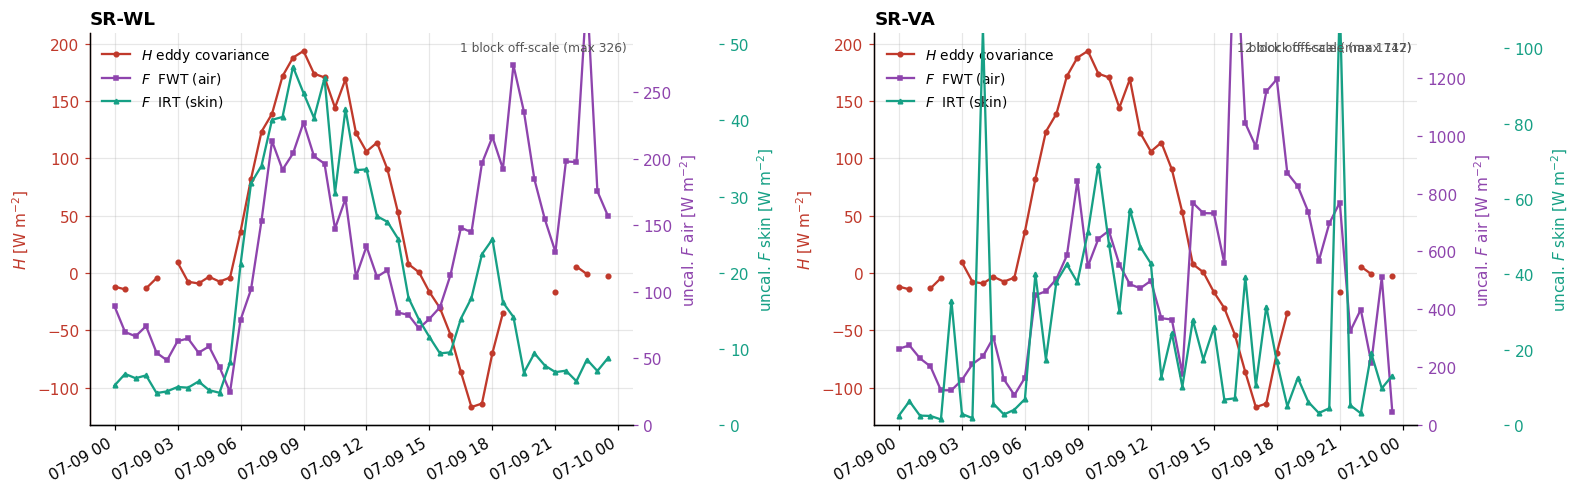

In [5]:
# Three quantities, three scales: H is O(100) W m-2, the air ramp flux O(10-300), and the
# skin ramp flux an order of magnitude smaller again. Each gets its own axis, and the axis
# is coloured to match its series so the reader is never guessing which scale to read.
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6), sharex=True)
C_H, C_AIR, C_SKIN = "#c0392b", "#8e44ad", "#16a085"

for ax, meth in zip(axes, ["WL", "VA"]):
    ax_air = ax.twinx()
    ax_skin = ax.twinx()
    ax_skin.spines["right"].set_position(("axes", 1.16))   # push the third axis outward

    l0, = ax.plot(d.index, d.H, "-o", ms=3, color=C_H, label="$H$ eddy covariance")
    l1, = ax_air.plot(d.index, d[f"{meth}_FWT_F"], "-s", ms=3, color=C_AIR,
                      label="$F$  FWT (air)")
    l2, = ax_skin.plot(d.index, d[f"{meth}_IRT_F"], "-^", ms=3, color=C_SKIN,
                       label="$F$  IRT (skin)")

    # robust limits: a single block whose tau collapses can send A/tau to thousands of
    # W m-2 and squash everything else flat. Clip the view, and say how much is off-scale.
    for a, col in ((ax_air, f"{meth}_FWT_F"), (ax_skin, f"{meth}_IRT_F")):
        v = d[col].to_numpy(float)
        hi_lim = np.nanpercentile(v, 97) * 1.15
        a.set_ylim(min(0, np.nanmin(v)), hi_lim)
        n_off = int(np.nansum(v > hi_lim))
        if n_off:
            a.annotate(f"{n_off} block off-scale (max {np.nanmax(v):.0f})",
                       xy=(0.99, 0.98), xycoords="axes fraction", ha="right", va="top",
                       fontsize=8, color="#555555")

    ax.set_ylabel("$H$ [W m$^{-2}$]", color=C_H)
    ax_air.set_ylabel("uncal. $F$ air [W m$^{-2}$]", color=C_AIR)
    ax_skin.set_ylabel("uncal. $F$ skin [W m$^{-2}$]", color=C_SKIN)
    for a, c in ((ax, C_H), (ax_air, C_AIR), (ax_skin, C_SKIN)):
        a.tick_params(axis="y", colors=c)
        a.spines["right"].set_color(c)
    ax.spines["left"].set_color(C_H)
    ax_air.grid(False)
    ax_skin.grid(False)
    ax.set_title(f"SR-{meth}", loc="left", fontweight="bold")
    ax.legend(handles=[l0, l1, l2], frameon=False, fontsize=9, loc="upper left")

fig.autofmt_xdate()
plt.tight_layout()

print("full ranges over the day [W m-2] — note how far apart the scales are, and that")
print("SR-VA's skin flux has a nocturnal block where the fitted tau collapses:")
print(pd.DataFrame({m: {"H_EC": f"{d.H.min():.0f} … {d.H.max():.0f}",
                        "F air":  f"{d[f'{m}_FWT_F'].min():.0f} … {d[f'{m}_FWT_F'].max():.0f}",
                        "F skin": f"{d[f'{m}_IRT_F'].min():.0f} … {d[f'{m}_IRT_F'].max():.0f}"}
                    for m in ("WL", "VA")}).to_string())

## 5. Calibrate α and regress against H

α is fitted **through the origin** on convective daytime blocks only (Rn > 50 W m⁻² and
H > 0), so the ramp direction never enters the calibration. With a single day there are
only ~20 usable blocks, so treat these α values as illustrative — the transferability study
behind this package needed 10–21 days spread over the record before α settled to ±10 %.

,method,scalar,z [m],alpha,alpha*z [m],r,RMSE,n
0,SR-WL,FWT,7.5,0.83,6.22,0.91,27.02,18
1,SR-WL,IRT,3.5,3.70,12.96,0.95,27.97,18
2,SR-VA,FWT,7.5,0.21,1.57,0.26,61.21,18
3,SR-VA,IRT,3.5,3.17,11.11,0.69,44.79,18


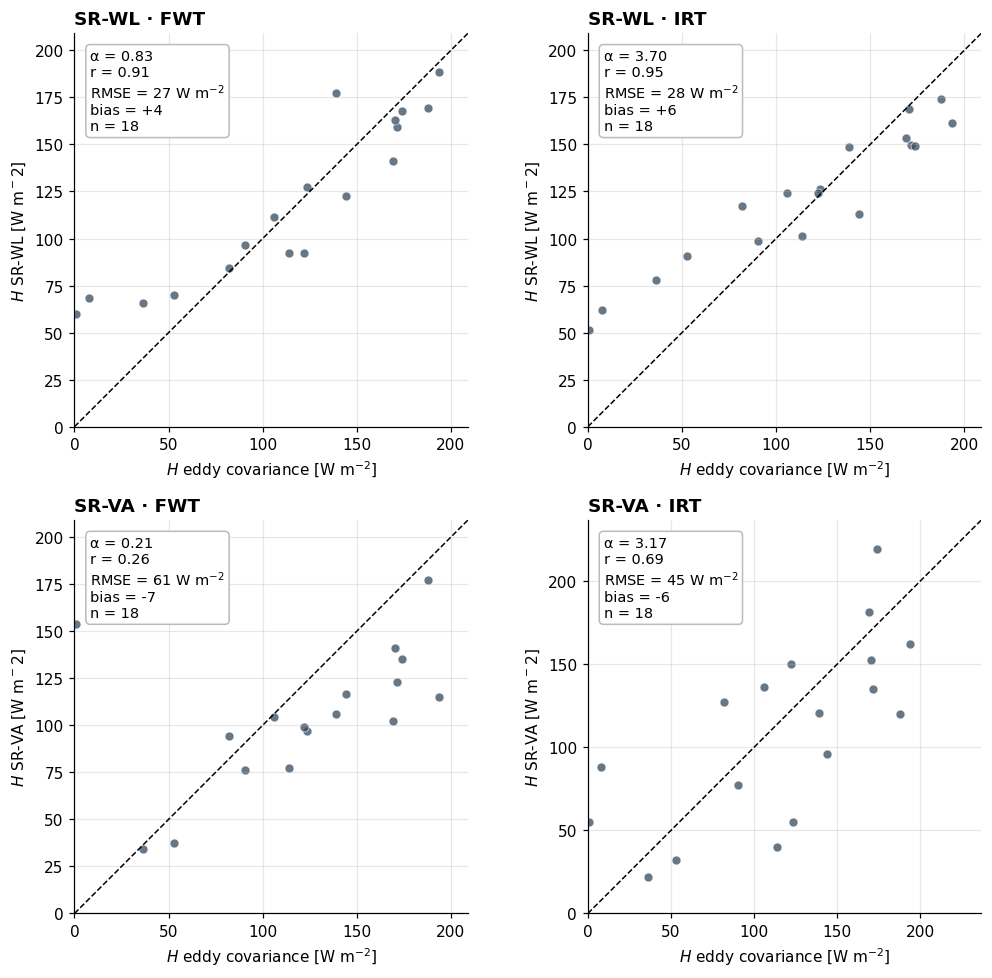

In [6]:
combos = [("WL", "FWT"), ("WL", "IRT"), ("VA", "FWT"), ("VA", "IRT")]
cal = d[d.daytime & (d.H > 0)]

fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.0))
fits = {}
for ax, (meth, col) in zip(axes.ravel(), combos):
    F, H = cal[f"{meth}_{col}_F"].to_numpy(), cal.H.to_numpy()
    m = np.isfinite(F) & np.isfinite(H)
    fit = fit_and_score(F[m], H[m])
    fits[(meth, col)] = fit
    est = fit.alpha * F[m]

    lim = [0, max(est.max(), H[m].max()) * 1.08]
    ax.scatter(H[m], est, s=34, color="#34495e", alpha=0.75, edgecolors="white", lw=0.5)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set(xlim=lim, ylim=lim, aspect="equal")
    ax.set_xlabel("$H$ eddy covariance [W m$^{-2}$]")
    ax.set_ylabel(f"$H$ SR-{meth} [W m$^{-2}$]")
    ax.set_title(f"SR-{meth} · {col}", loc="left", fontweight="bold")
    ax.text(0.04, 0.96, f"α = {fit.alpha:.2f}\nr = {fit.r:.2f}\nRMSE = {fit.rmse:.0f} W m$^{{-2}}$\n"
                        f"bias = {fit.mbe:+.0f}\nn = {fit.n}",
            transform=ax.transAxes, va="top", fontsize=9.5,
            bbox=dict(boxstyle="round", fc="white", ec="#bbb"))
plt.tight_layout()

pd.DataFrame([{"method": f"SR-{m}", "scalar": c, "z [m]": Z[c], "alpha": f.alpha,
               "alpha*z [m]": f.alpha * Z[c], "r": f.r, "RMSE": f.rmse, "n": f.n}
              for (m, c), f in fits.items()]).round(2)

Two things to read off this table rather than the α column alone:

- **α and z are not separately identifiable.** Only their product enters the flux, so `α·z`
  is the quantity the data constrain. Comparing raw α between the air and skin channels
  compares two different height conventions, not two different physics.
- **r is scale-invariant.** It does not depend on α at all, so it — not RMSE — is the honest
  measure of which detector and which scalar tracks the flux better.

## 6. SR-VA on the skin temperature: does the fitted period earn its place?

SR-VA divides the amplitude by a fitted ramp period, and on a 1 Hz skin temperature that
period is the least trustworthy thing in the calculation — here it ranges from about 15 s to
over 300 s across the day's blocks. `period_mode="unit"` sets tau = 1 and uses the
**amplitude alone**, `F = rho cp z A`, folding the duration into the calibration coefficient.

Whether that helps depends on the lag, because the Chen criterion optimises `|S3(r)|/r` —
the right target when you want a period, the wrong one once you have decided to discard it.
The sweep below varies the lag with the period dropped.

IRT: classical A/τ (Chen)      r = +0.69
IRT: amplitude only, Chen lag  r = +0.70
IRT: amplitude only,    2 s lag  r = +0.78   <-- best


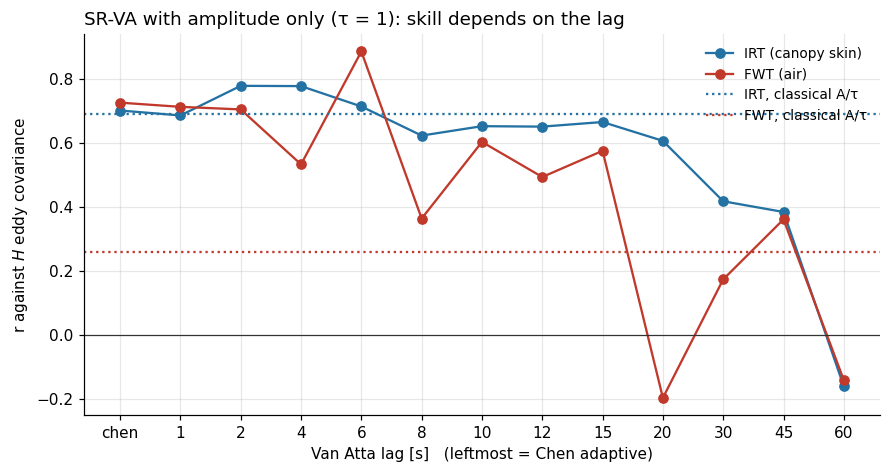

In [7]:
lags = ["chen", 1, 2, 4, 6, 8, 10, 12, 15, 20, 30, 45, 60]
blocks = {t: {c: prepare_block(g[c].to_numpy(), fs=FS) for c in ("FWT", "IRT")}
          for t, g in hi.groupby(pd.Grouper(freq="30min"))}

sweep = []
for lag in lags:
    row = {"lag": lag}
    for col in ("FWT", "IRT"):
        det = VanAttaDetector(fs=FS, lag=lag, period_mode="unit")
        A = np.array([det.detect(blocks[t][col].values).amplitude for t in cal.index])
        F = ramp_flux(A, period=1.0, z=Z[col])          # tau = 1: amplitude only
        row[f"r_{col}"] = fit_and_score(F, cal.H.to_numpy()).r
    sweep.append(row)
sweep = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
x = np.arange(len(lags))
ax.plot(x, sweep.r_IRT, "-o", color="#2471a3", label="IRT (canopy skin)")
ax.plot(x, sweep.r_FWT, "-o", color="#c0392b", label="FWT (air)")
ax.axhline(fits[("VA", "IRT")].r, color="#2471a3", ls=":", lw=1.5,
           label="IRT, classical A/τ")
ax.axhline(fits[("VA", "FWT")].r, color="#c0392b", ls=":", lw=1.5,
           label="FWT, classical A/τ")
ax.axhline(0, color="#333", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([str(v) for v in lags])
ax.set_xlabel("Van Atta lag [s]   (leftmost = Chen adaptive)")
ax.set_ylabel("r against $H$ eddy covariance")
ax.set_title("SR-VA with amplitude only (τ = 1): skill depends on the lag", loc="left")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

best = sweep.loc[sweep.r_IRT.idxmax()]
print(f"IRT: classical A/τ (Chen)      r = {fits[('VA', 'IRT')].r:+.2f}")
print(f"IRT: amplitude only, Chen lag  r = {sweep.r_IRT.iloc[0]:+.2f}")
print(f"IRT: amplitude only, {str(best.lag):>4} s lag  r = {best.r_IRT:+.2f}   <-- best")

**Dropping the period costs nothing and the lag choice matters more.** On this day the
classical `A/tau` reaches r ≈ 0.69 on the skin channel; the amplitude alone at the same Chen
lag is essentially identical, and a shorter fixed lag lifts it further. Nothing is lost by
discarding a quantity that cannot be estimated reliably, and something is usually gained.

How much is gained is day-dependent, and worth stating plainly. On a different day from this
record (24 June 2023) the classical form collapsed outright — r = −0.07, with per-block tau
spanning 15–324 s — while the amplitude alone at a fixed 15 s lag recovered r = 0.59. The
failure mode is the noisy denominator, and it appears intermittently rather than always.

The practical recommendation for a low-rate radiometric temperature is therefore
`period_mode="unit"` with a fixed lag, chosen by a sweep like this one on a handful of days
rather than from a single day's peak.

## 7. Flux direction and stability from the radiometer alone (Ta from the sensor body)

The ramp amplitude says how big the exchange is, not which way it goes. Three candidates,
none of which needs a sonic:

1. `sign_from_skewness` on the **air** ramp — a warm ramp rises gradually and collapses
   sharply, so the increment skewness is negative;
2. the same on the **skin** ramp;
3. `sign_from_gradient` — the **surface-air temperature difference** `dT = IRT − SBT`, taken
   from the two channels of the one radiometer. The housing thermistor tracks air rather
   than canopy, so dT is a direct thermodynamic statement: surface warmer than air means
   heat goes up. No time-domain statistics at all.

The first thing to check is whether the housing really behaves like an air sensor here.

In [8]:
b = hi.resample("30min").mean()
d = d.join(b[["SBT"]].rename(columns={"SBT": "SBT_mean"}))
d = d.join(hi.IRT.resample("30min").mean().rename("IRT_mean"))
d["dT"] = surface_air_difference(d.IRT_mean, d.SBT_mean)
day_all = d[d.daytime]

print(f"SBT vs FWT over the day:  r = {b.SBT.corr(b.FWT):.3f}, "
      f"mean SBT − FWT = {(b.SBT - b.FWT).mean():+.2f} K")
print(f"midday (11–15 h) FWT {b.FWT.between_time('11:00','15:00').mean():.1f} °C, "
      f"SBT {b.SBT.between_time('11:00','15:00').mean():.1f} °C, "
      f"IRT {b.IRT.between_time('11:00','15:00').mean():.1f} °C")

SBT vs FWT over the day:  r = 0.970, mean SBT − FWT = -0.40 K
midday (11–15 h) FWT 28.6 °C, SBT 28.7 °C, IRT 27.7 °C


The housing now tracks the fine wire closely in both shape and level — a housing thermistor
behaving as an air proxy should. Whether that makes it a good flux-direction indicator is a
separate question, settled empirically below.

In [9]:
sources = {
    "skewness · FWT (air ramp)":  day_all.FWT_sign,
    "skewness · IRT (skin ramp)": day_all.IRT_sign,
    "gradient · IRT − SBT":       sign_from_gradient(day_all.IRT_mean, day_all.SBT_mean),
    "gradient · IRT − FWT":       sign_from_gradient(day_all.IRT_mean,
                                                     b.FWT.reindex(day_all.index)),
}
truth = np.sign(day_all.H)
pd.DataFrame([{"sign source": k,
               "agrees with sign(H_EC)": f"{100 * np.mean(np.asarray(v) == truth):.0f} %",
               "says 'upward' in": f"{int(np.nansum(np.asarray(v) > 0))}/{len(day_all)} blocks"}
              for k, v in sources.items()])

,sign source,agrees with sign(H_EC),says 'upward' in
0,skewness · FWT (air ramp),88 %,17/24 blocks
1,skewness · IRT (skin ramp),83 %,22/24 blocks
2,gradient · IRT − SBT,25 %,0/24 blocks
3,gradient · IRT − FWT,62 %,9/24 blocks


**The ramp-shape conventions work here and the temperature-gradient one does not.** The air
ramp skewness is right in ~88 % of daytime blocks and the skin ramp in ~83 %, while dT is
right in only ~25 %: the canopy skin sits about 1 K BELOW the air through the whole day, so
the gradient says "downward" while the tower measures an upward flux.

That is not a sensor fault, and it is worth understanding before reusing the diagnostic.
A transpiring, irrigated canopy is evaporatively cooled below air temperature; the
radiometer sees those cool leaves, while the tower's flux footprint also includes sunlit
soil and branch surfaces that are far hotter. The two are not measuring the same surface, so
their signs need not agree. The same footprint mismatch is why the skin-channel calibration
is noisier than the air one at most sites.

**A caution about this channel that only a long record reveals.** Running the same
diagnostic on this instrument in 2023 gives the opposite answer — dT positive all day and
96 % agreement with the tower — but for the wrong reason. In 2023 the housing thermistor
read about 10 K BELOW two fine-wire thermocouples that agreed with each other to 0.03 K, so
dT was biased positive by roughly that amount and happened to land on the right side of zero.
A step change between the 2023 and 2024 seasons brought the housing to within 0.15 K of the
fine wires, where it has stayed:

| midday (11–15 h) | 2023-06 | 2024-06 | 2025-06 | 2026-06 |
|---|---|---|---|---|
| dT = Ts − T_body [K] | +3.5 | −0.2 | −1.2 | −3.5 |

An agreement statistic computed inside the biased epoch would have looked excellent.
**Validate the housing channel against an independent air measurement before trusting dT** —
one field season is not enough to notice a 10 K offset that is stable in time.

Elsewhere the diagnostic does earn its place: across three other sites it was 80–87 % correct
with a fitted offset, against 61–78 % for the ramp skewness of the same skin temperature. It
is site- and epoch-specific, not universal, and this notebook is the counterexample.

For the rest of the notebook the direction comes from the **air ramp skewness**, the best
temperature-only source available here.

## 8. Close the energy balance and get ET

With H from surface renewal — direction from the air-ramp skewness of section 7 — LE follows as the
residual `LE = Rn − G − H`, and daily ET is its time integral. Because α was fitted on these
same blocks, these are in-sample numbers: a demonstration of the chain, not a validation of
it.

,ET [mm]
SR-WL · FWT,5.88
SR-WL · IRT,5.64
SR-VA · FWT,6.73
SR-VA · IRT,5.90
EC residual (Rn−G−H),5.64
EC measured LE,5.33


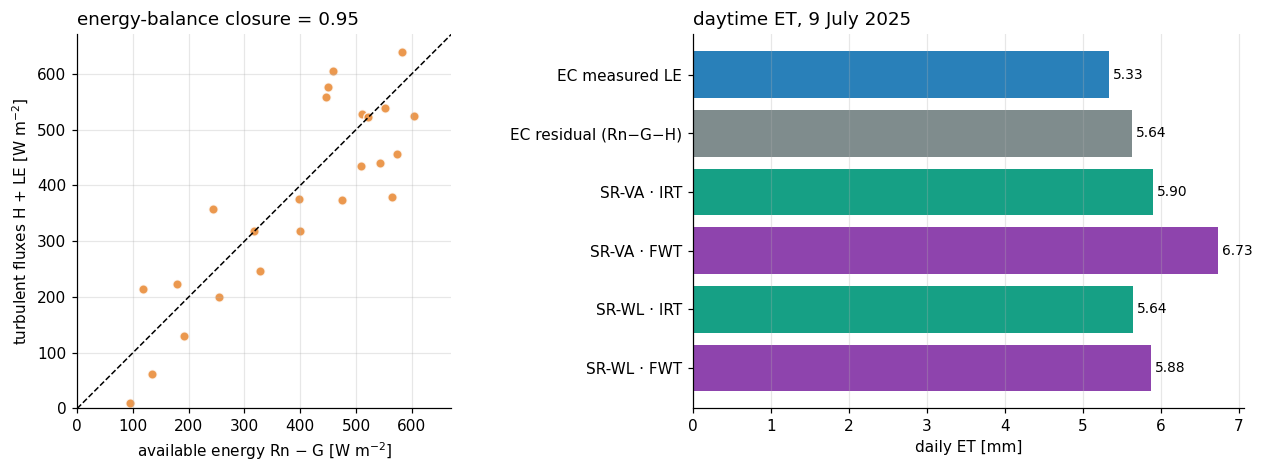

In [10]:
LAMBDA = 2.45e6
day = d[d.daytime].copy()

et = {}
for (meth, col), fit in fits.items():
    H_sr = sensible_heat(day[f"{meth}_{col}_F"].to_numpy(), fit.alpha,
                         sign=day.FWT_sign.to_numpy())      # air ramp skewness
    le = latent_heat_residual(day.NETRAD.to_numpy(), day.G.to_numpy(), H_sr)
    et[f"SR-{meth} · {col}"] = daily_et(le, block_s=BLOCK_S)

et["EC residual (Rn−G−H)"] = daily_et(
    latent_heat_residual(day.NETRAD.to_numpy(), day.G.to_numpy(), day.H.to_numpy()),
    block_s=BLOCK_S)
et["EC measured LE"] = daily_et(day.LE.to_numpy(), block_s=BLOCK_S)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.4))

avail = (day.NETRAD - day.G).to_numpy()
turb = (day.H + day.LE).to_numpy()
lim = [0, max(avail.max(), turb.max()) * 1.05]
axa.scatter(avail, turb, s=38, color="#e67e22", alpha=0.8, edgecolors="white")
axa.plot(lim, lim, "k--", lw=1)
sl = np.sum(avail * turb) / np.sum(avail ** 2)
axa.set(xlim=lim, ylim=lim, aspect="equal",
        xlabel="available energy Rn − G [W m$^{-2}$]",
        ylabel="turbulent fluxes H + LE [W m$^{-2}$]")
axa.set_title(f"energy-balance closure = {sl:.2f}", loc="left")

names = list(et)
axb.barh(names, [et[k] for k in names],
         color=["#8e44ad", "#16a085", "#8e44ad", "#16a085", "#7f8c8d", "#2980b9"])
axb.set_xlabel("daily ET [mm]")
axb.set_title("daytime ET, 9 July 2025", loc="left")
for i, k in enumerate(names):
    axb.text(et[k] + 0.05, i, f"{et[k]:.2f}", va="center", fontsize=9)
axb.grid(axis="y", alpha=0)
plt.tight_layout()

pd.Series(et).round(2).to_frame("ET [mm]")

The measured-LE bar sits below the residual bars because this tower, like most, does not
close its energy balance — the residual method assigns the missing energy to LE. That gap
is a property of the site, not of surface renewal, and it is why calibrating against a
closure-corrected H is preferable when one is available.

## Takeaways

1. **SR-WL works on both channels here, and the canopy skin is not the weaker one**
   (r = 0.95 skin, 0.91 air): a single multiplicative constant reproduces the tower's H
   across the day from a radiometer alone. That is the case for the method — no sonic, no
   fast thermometer. It is one favourable day, chosen partly for that skill; other days in
   the same record are worse.
2. **SR-VA trails SR-WL on both channels** (0.69 skin, 0.26 air) because it divides by a
   fitted period that a 1 Hz record cannot pin down. `period_mode="unit"` discards the period
   and never does worse; on a bad day it is the difference between r = −0.07 and r = 0.59.
3. **No flux-direction convention is universal.** Here the ramp skewness works (88 % air,
   83 % skin) and the surface-air gradient does not (25 %), because a transpiring canopy sits
   below air temperature while the tower still measures an upward flux. On the same
   instrument in 2023 the ranking was reversed — by a 10 K bias in the housing thermistor.
   Check any sign convention against a reference before relying on it, and check the housing
   channel against an independent air sensor before using dT at all.
4. Compare `α·z`, not α, whenever the length-scale convention differs — only the product is
   identifiable from data.
5. One day demonstrates the method and is nowhere near enough to calibrate it: plan on
   10–21 days spread across conditions, not one continuous campaign.